### Importation librairies

In [2]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import os
from torchvision import transforms
from torchvision.transforms import v2 
from tqdm import tqdm
from PIL import Image, ImageOps

### Exploration & Visualisation 

In [7]:
root_dir = "IDC_regular_ps50_idx5"  

healthy_images = []
cancer_images = []

for patient_folder in os.listdir(root_dir):
    patient_path = os.path.join(root_dir, patient_folder)
    if os.path.isdir(patient_path):
        healthy_path = os.path.join(patient_path, "0")
        if os.path.isdir(healthy_path):
            healthy_images += [os.path.join(healthy_path, img) for img in os.listdir(healthy_path)]
        cancer_path = os.path.join(patient_path, "1")
        if os.path.isdir(cancer_path):
            cancer_images += [os.path.join(cancer_path, img) for img in os.listdir(cancer_path)]

print(f"Nombre d'images saines : {len(healthy_images)}")
print(f"Nombre d'images cancéreuses : {len(cancer_images)}")

Nombre d'images saines : 129025
Nombre d'images cancéreuses : 57253


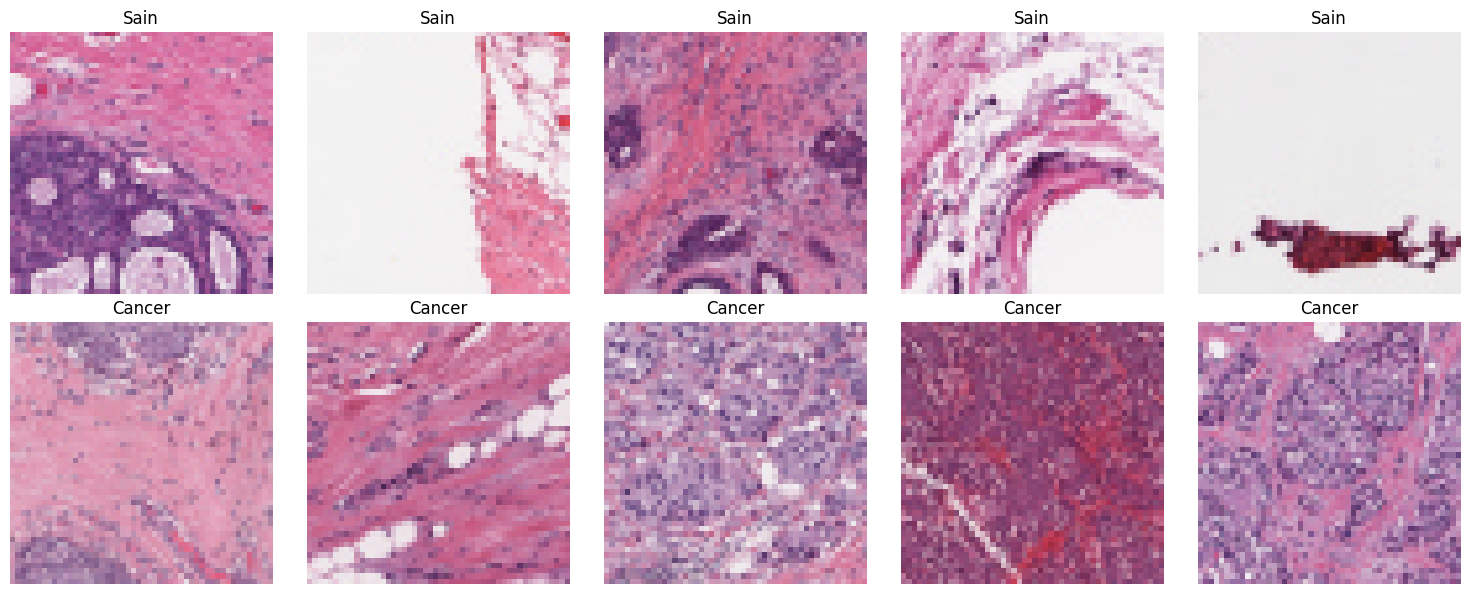

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    img_healthy = Image.open(random.choice(healthy_images))
    axes[0, i].imshow(img_healthy)
    axes[0, i].set_title("Sain")
    axes[0, i].axis("off")
    img_cancer = Image.open(random.choice(cancer_images))
    axes[1, i].imshow(img_cancer)
    axes[1, i].set_title("Cancer")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

In [9]:
from PIL import Image

# Taille de 10 images saines au hasard
healthy_shapes = [Image.open(path).size for path in random.sample(healthy_images, 10)]
# Taille de 10 images cancéreuses au hasard
cancer_shapes = [Image.open(path).size for path in random.sample(cancer_images, 10)]

print("Taille d'images saines (exemple) :", healthy_shapes)
print("Taille d'images cancéreuses (exemple) :", cancer_shapes)


Taille d'images saines (exemple) : [(50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50)]
Taille d'images cancéreuses (exemple) : [(50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50)]


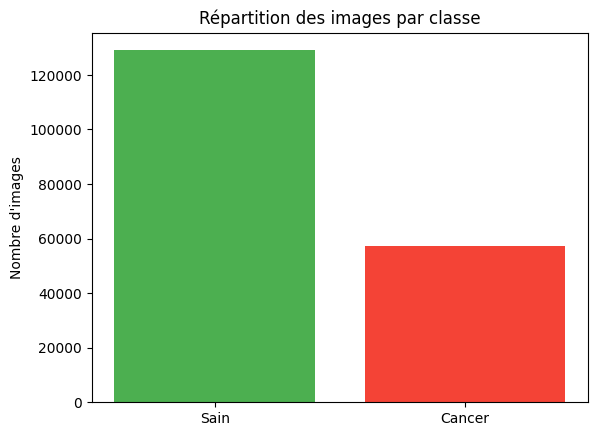

In [10]:
import matplotlib.pyplot as plt

labels = ["Sain", "Cancer"]
counts = [len(healthy_images), len(cancer_images)]

plt.bar(labels, counts, color=["#4CAF50", "#F44336"])
plt.title("Répartition des images par classe")
plt.ylabel("Nombre d'images")
plt.show()

### Data augmentation

In [20]:
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import os

class IDCFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        self.labels = []
        self.transform = transform

        for root, _, files in os.walk(root_dir):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    full_path = os.path.join(root, file)
                    label = int(os.path.basename(os.path.dirname(full_path)))
                    self.image_paths.append(full_path)
                    self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

In [22]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

### Modèle Resnet

In [23]:
dataset = IDCFolderDataset(root_dir="C:/Users/mahmo/OneDrive/Documents/Ruban rose/ruban_rose/IDC_regular_ps50_idx5", transform=None)

# Split 80/20
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Ajouter les transforms après le split
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [24]:
from torchvision import models
import torch.nn as nn
import torch.optim as optim
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights='IMAGENET1K_V2')

# Adapter la dernière couche
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 1)
)
model = model.to(device)

# Freeze sauf fc
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\mahmo/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:36<00:00, 2.84MB/s]


In [25]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0., 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.float().to(device)
        optimizer.zero_grad()
        outputs = model(inputs).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total += inputs.size(0)
    return total_loss / total, correct / total

In [26]:
def validate(model, loader, criterion):
    model.eval()  # mode évaluation
    total_loss, correct, total = 0., 0, 0

    with torch.no_grad():  # pas de calcul de gradient
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.float().to(device)

            outputs = model(inputs).squeeze(1)  # [B] au lieu de [B, 1]
            loss = criterion(outputs, labels)

            total_loss += loss.item() * inputs.size(0)

            preds = (torch.sigmoid(outputs) > 0.5).long()
            correct += (preds == labels.long()).sum().item()
            total += inputs.size(0)

    return total_loss / total, correct / total

In [ ]:
EPOCHS = 10
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)
    print(f"Epoch {epoch+1}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")